In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [8]:
from langchain_openai import ChatOpenAI 

llm= ChatOpenAI(model="gpt-4o")
llm.invoke("Hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-Bl9kwGNF7wWQztzMeJwl3RJQi7M0S', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--18c07d8d-deb2-45ad-a2e5-a6a6e21440ce-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
from langgraph.types import Command

In [12]:
from langgraph.prebuilt import create_react_agent

In [15]:
def add_number(state):
    result= state["num1"] + state["num2"]
    print(f"addition is {result}")
    return Command(goto="multiply", update={"sum":result})

In [18]:
state= {"num1": 10, "num2": 20}
state

{'num1': 10, 'num2': 20}

In [19]:
add_number(state)

addition is 30


Command(update={'sum': 30}, goto='multiply')

### Creating one dummy multiagent

It is for network/collabrating multiagent.

In [20]:
from langchain_core.tools import tool

In [23]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    
    return

In [24]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    
    return

In [35]:
llm_with_tool= llm.bind_tools([transfer_to_addition_expert])

In [27]:
response= llm_with_tool.invoke("Hi")
response.content

'Hello! How can I assist you today?'

In [28]:
response.tool_calls

[]

In [36]:
response= llm_with_tool.invoke("what is 2+2?")
response.content

''

In [37]:
response.tool_calls 

[{'name': 'transfer_to_addition_expert',
  'args': {},
  'id': 'call_Bcmb26JbDCOyIWsFa8qXSRrW',
  'type': 'tool_call'}]

In [43]:
from typing_extensions import Literal
from langgraph.graph import MessagesState, StateGraph, START, END

In [78]:
system_prompt= (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

In [79]:
messages= [{"role": "system", "content": system_prompt}] + ["can you tell me the addition of 2 and 2?"]

In [80]:
messages

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

In [71]:
# Agent1 
def additional_expert(state: MessagesState) -> Command[Literal["multiplication_expert", "__end__"]]:
    system_prompt= (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

    messages= [{"role": "system", "content": system_prompt}] + state["messages"]

    ai_msg= llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)

    if len(ai_msg.tool_calls) > 0:
        tool_call_id= ai_msg.tool_calls[-1]["id"]
        tool_msg= {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }

        return Command(goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]})
    
    return {"messages": [ai_msg]}

In [70]:
# Agent2
def multiplication_expert(state: MessagesState) -> Command[Literal["additional_expert", "__end__"]]:
    system_prompt= (
        "You are a multiplication expert, you can ask an addition expert for help with addition."
        "Always do your portion of calculation before the handoff."
    )

    messages= [{"role": "system", "content": system_prompt}] + state["messages"]

    ai_msg= llm.bind_tools([transfer_to_addition_expert]).invoke(messages)

    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg= {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }

        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]}) 
    return {"messages": [ai_msg]}

In [72]:
graph= StateGraph(MessagesState)

In [73]:
graph.add_node("additional_expert", additional_expert)
graph.add_node("multiplication_expert", multiplication_expert)

In [74]:
graph.add_edge(START, "additional_expert")
# graph.add_edge("multiplication_expert", "additional_expert")

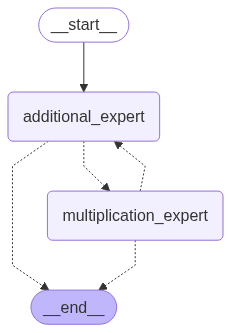

In [60]:
graph.compile()

In [75]:
app= graph.compile()

In [81]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='f373b487-c67c-48b3-b692-5a48f1adc3aa'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_pKmpZ4baiocYiO6wMj9aFpMq', 'function': {'arguments': '{}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 86, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BlBJhPMmF0OatWIweAiO0yKYUDHLn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--4b6e29b1-188a-49a9-9b75-9f1c8b916631-0', tool_calls=[{'name': 'transfer_to_multiplication_expert', 

### With Realtime tool

In [88]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool= DuckDuckGoSearchRun()
search_tool.invoke("Who is the pm of inda") # We have typo error while invoke but still getting correct result

"List of all Prime Ministers of India till 2025: Narendra Modi is the current and 14th Prime Minister of India who assumed office on 10 June 2024. Jawaharlal Nehru is the first and the longest ... The prime minister of India is the head of government and has the responsibility for executive power. The president's constitutional duty is to preserve, protect and defend the Constitution and the law per article 60. In the constitution of India, the prime minister is mentioned in only four of its articles (articles 74, 75, 78 and 366). The Prime Minister, Shri Narendra Modi addressed the 11th International Day of Yoga (IYD) event in Visakhapatnam, Andhra Pradesh today. ... Shri Narendra Modi was sworn-in as India's Prime Minister for the third time on 9th June 2024, following another decisive victory in the 2024 Parliamentary elections. This victory marked the third ... The list of Indian Prime Ministers begins with Jawaharlal Nehru, who became the first Prime Minister in 1947 and consist .

In [89]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

TAVILY_API_KEY= os.getenv("TAVILY_API_KEY")

search_tool= TavilySearchResults(tavily_api_key=TAVILY_API_KEY) # We have typo error while invoke but still getting correct result
search_tool.invoke("Who is the pm of inda")

[{'title': 'Prime Minister of India - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/Prime_Minister_of_India',
  'content': 'Rao](https://en.wikipedia.org/wiki/P._V._Narasimha_Rao "P. V. Narasimha Rao"), [Atal Bihari Vajpayee](https://en.wikipedia.org/wiki/Atal_Bihari_Vajpayee "Atal Bihari Vajpayee"), [Manmohan Singh](https://en.wikipedia.org/wiki/Manmohan_Singh "Manmohan Singh"), and [Narendra Modi. Modi](https://en.wikipedia.org/wiki/Narendra_Modi "Narendra Modi") is the current prime minister of India, serving since [26 May 2014](https://en.wikipedia.org/wiki/First_swearing-in_ceremony_of_Narendra_Modi "First [...] The **prime minister of India** ([ISO](https://en.wikipedia.org/wiki/ISO_15919 "ISO 15919"): _Bhārata kē Pradhānamantrī_) is the [head of government](https://en.wikipedia.org/wiki/Head_of_government "Head of government")[[2]](https://en.wikipedia.org/wiki/Prime_Minister_of_India#cite_note-2) of the [Republic of India](https://en.wikipedia.org/wiki/Republic_of_India "

In [90]:
search_tool.invoke("who is a current pm of uk?")

[{'title': 'Prime Minister - GOV.UK',
  'url': 'https://www.gov.uk/government/ministers/prime-minister',
  'content': '## Contents\n\n## Responsibilities\n\nThe Prime Minister is the leader of His Majesty’s Government and is ultimately responsible for the policy and decisions of the government.\n\nAs leader of the UK government the Prime Minister also:\n\n## Current role holder\n\n### The Rt Hon Sir Keir Starmer KCB KC MP\n\nSir Keir Starmer\xa0became Prime Minister on 5 July 2024.\n\n## Education [...] Keir qualified as a barrister in 1987 working in private practice before working as a legal advisor to the Northern Ireland Policing Board.\n\nHe was appointed Queen’s Counsel (QC) in 2002.\n\nIn 2008, Keir was appointed Director of Public Prosecutions, leading the Crown Prosecution Service until 2013.\n\nHe received a knighthood in 2014 for services to criminal justice.\n\n## Personal Life\n\nKeir is married and has two children.\n\n[More about this person](/government/people/keir-star

In [93]:
from langchain_experimental.utilities import PythonREPL

In [94]:
repl= PythonREPL()

In [97]:
code = """
x = 5
y = x * 2
print(y)
"""

In [98]:
repl.run(code)

'10\n'